# Cleaning

BASIC INFO
Shape:             15,410 rows × 37 columns
Year range:        1960 – 2020
Unique countries:  264
Duplicate rows:    0

MISSING VALUES (sorted by % missing)
                                                                                                   Missing  % Missing
Children in employment, study and work, female (% of female children in employment, ages 7-14)       15228       98.8
Children in employment, study and work, male (% of male children in employment, ages 7-14)           15228       98.8
Children in employment, work only, female (% of female children in employment, ages 7-14)            15228       98.8
Children in employment, work only, male (% of male children in employment, ages 7-14)                15228       98.8
Children in employment, male (% of male children ages 7-14)                                          15129       98.2
Children in employment, female (% of female children ages 7-14)                                      15129       98.2
Childr

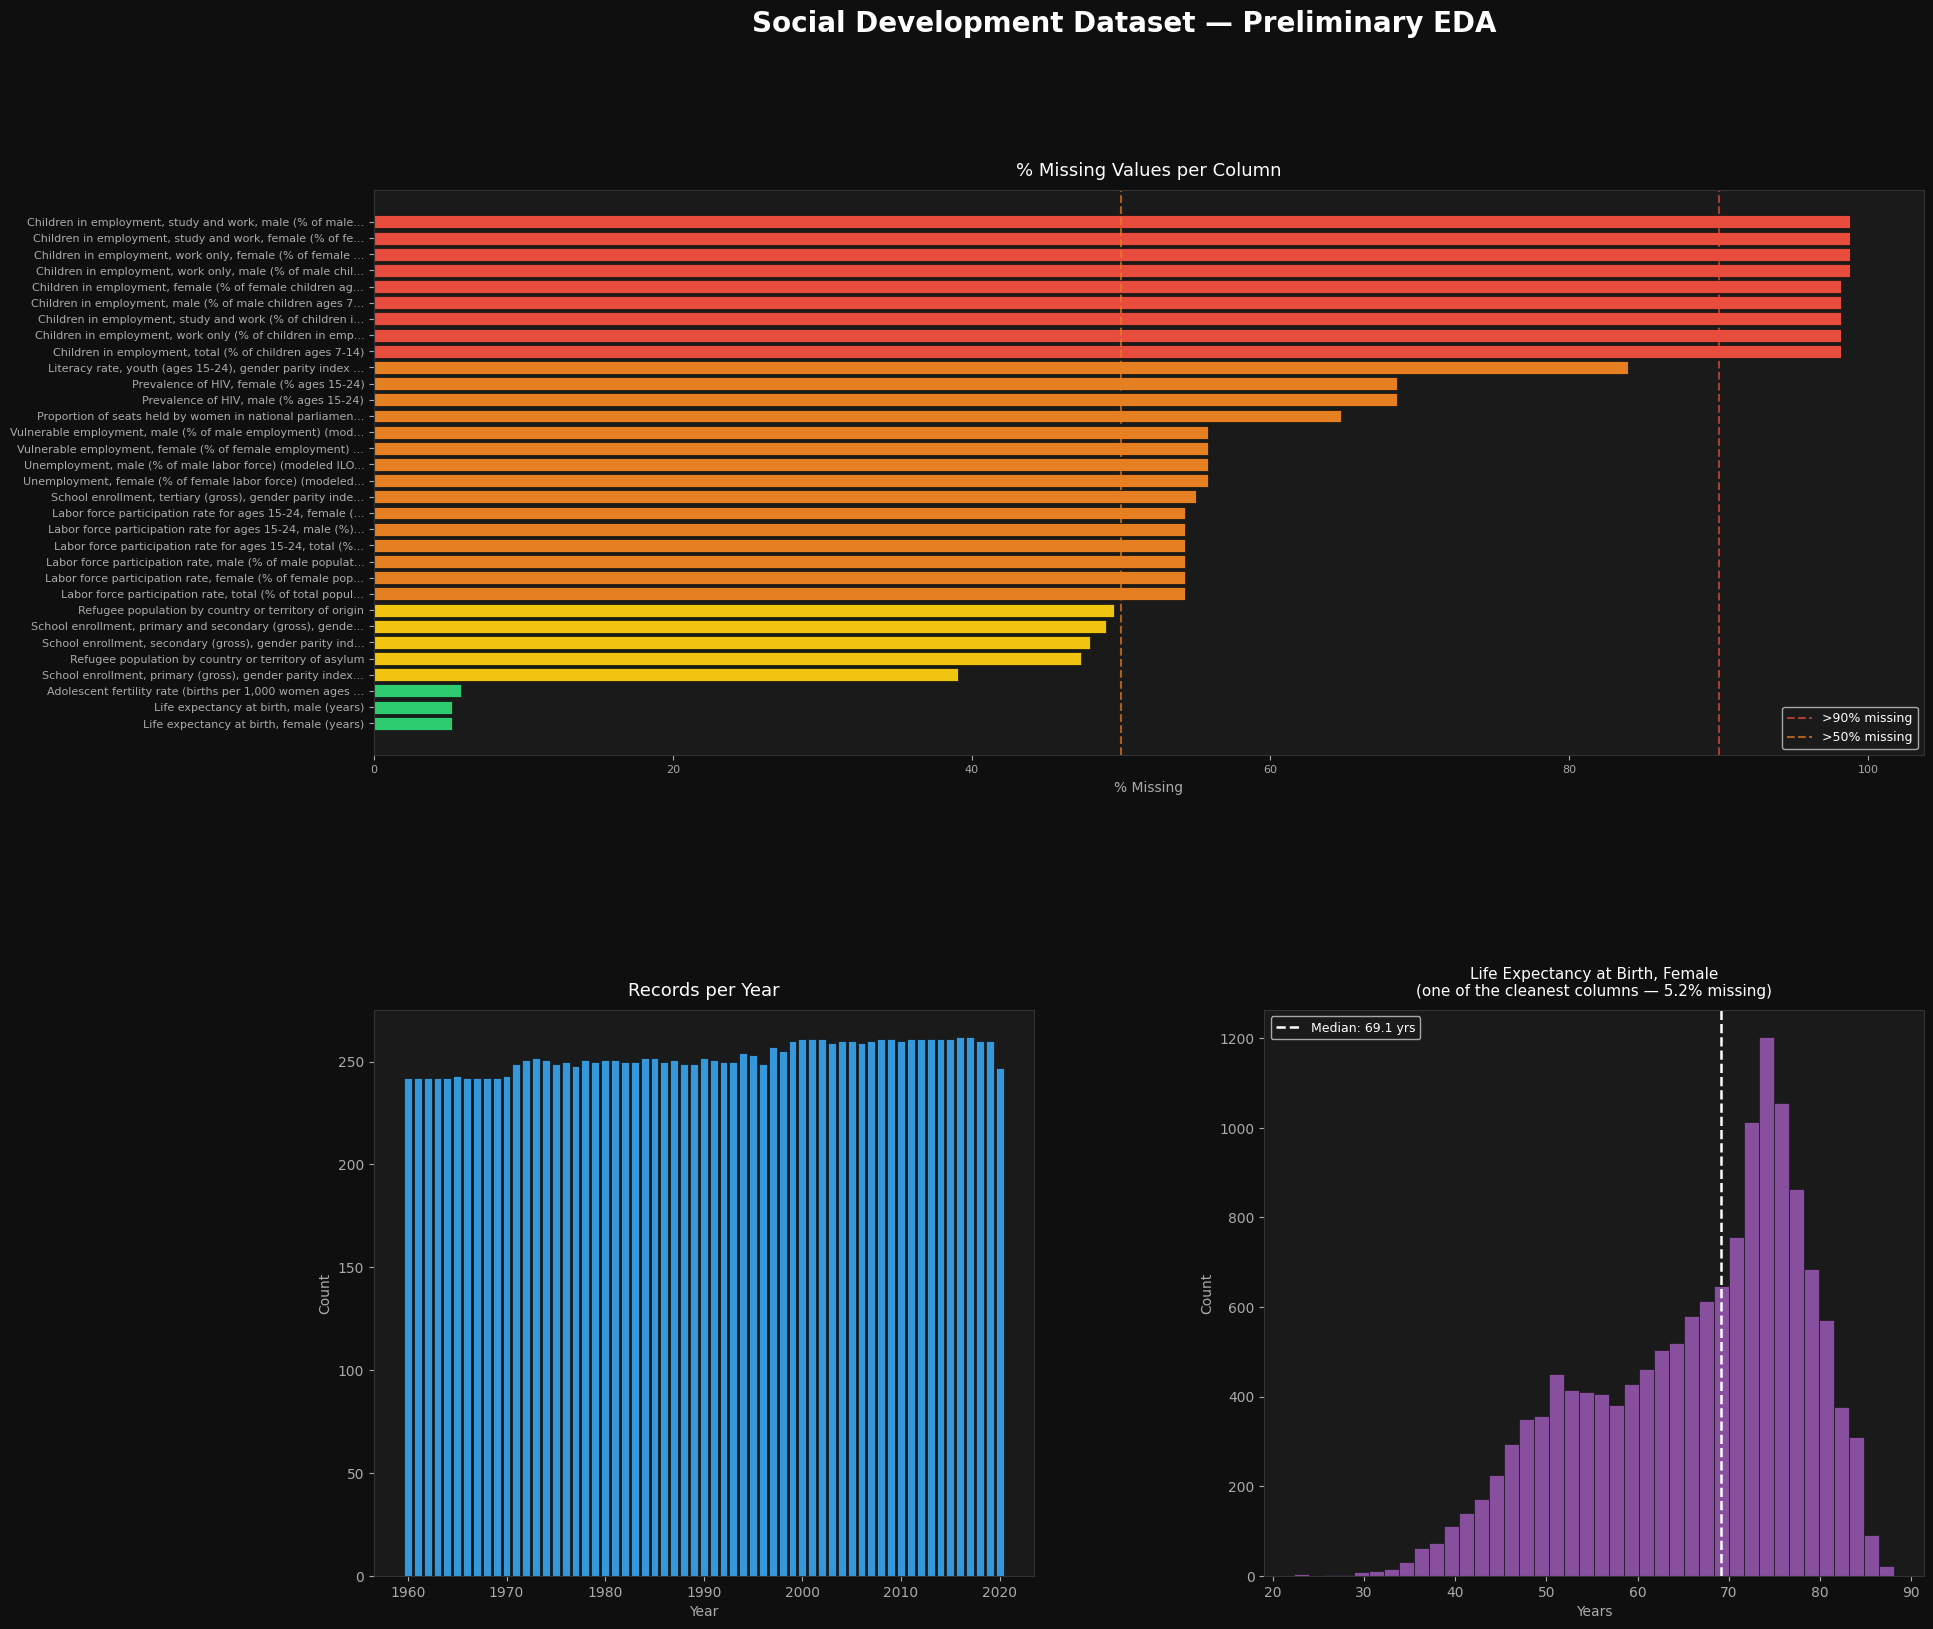

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# ── LOAD ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("social-development.csv")

# Shorten column names for readability
short_names = {c: c.replace("average_value_", "") for c in df.columns}
df = df.rename(columns=short_names)
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "Year"]

# ── PRINT SUMMARY ─────────────────────────────────────────────────────────────
print("=" * 60)
print("BASIC INFO")
print("=" * 60)
print(f"Shape:             {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Year range:        {df['Year'].min()} – {df['Year'].max()}")
print(f"Unique countries:  {df['Country Name'].nunique()}")
print(f"Duplicate rows:    {df.duplicated().sum()}")

print("\n" + "=" * 60)
print("MISSING VALUES (sorted by % missing)")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"Missing": missing, "% Missing": missing_pct})
missing_df = missing_df[missing_df["Missing"] > 0].sort_values("% Missing", ascending=False)
print(missing_df.to_string())

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS (numeric columns)")
print("=" * 60)
print(df[numeric_cols].describe().round(2).to_string())

print("\n" + "=" * 60)
print("COLUMNS WITH > 90% MISSING (nearly unusable)")
print("=" * 60)
nearly_empty = missing_pct[missing_pct > 90].index.tolist()
for col in nearly_empty:
    print(f"  {missing_pct[col]:.1f}% missing  →  {col}")

# ── VISUALIZATIONS ────────────────────────────────────────────────────────────
BG_DARK = "#0f0f0f"
BG_AX   = "#1a1a1a"

fig = plt.figure(figsize=(20, 18), facecolor=BG_DARK)
fig.suptitle("Social Development Dataset — Preliminary EDA",
             color="white", fontsize=20, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── PLOT 1: Missing values heatmap ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])   # full width
ax1.set_facecolor(BG_AX)

pct_vals = missing_pct[numeric_cols].sort_values(ascending=True)
short_labels = [c[:55] + "..." if len(c) > 55 else c for c in pct_vals.index]
colors = ["#e74c3c" if v > 90 else "#e67e22" if v > 50 else "#f1c40f" if v > 20 else "#2ecc71"
          for v in pct_vals.values]

bars = ax1.barh(short_labels, pct_vals.values, color=colors,
                edgecolor=BG_DARK, linewidth=0.5)
ax1.axvline(90, color="#e74c3c", linestyle="--", linewidth=1.5, alpha=0.7, label=">90% missing")
ax1.axvline(50, color="#e67e22", linestyle="--", linewidth=1.5, alpha=0.7, label=">50% missing")
ax1.set_title("% Missing Values per Column", color="white", fontsize=13, pad=10)
ax1.set_xlabel("% Missing", color="#aaaaaa")
ax1.tick_params(colors="#aaaaaa", labelsize=8)
for spine in ax1.spines.values(): spine.set_color("#333333")
ax1.legend(facecolor=BG_AX, labelcolor="white", fontsize=9)

# ── PLOT 2: Records per year ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(BG_AX)

records_per_year = df.groupby("Year").size()
ax2.bar(records_per_year.index, records_per_year.values,
        color="#3498db", edgecolor=BG_DARK, linewidth=0.5)
ax2.set_title("Records per Year", color="white", fontsize=13, pad=10)
ax2.set_xlabel("Year", color="#aaaaaa")
ax2.set_ylabel("Count", color="#aaaaaa")
ax2.tick_params(colors="#aaaaaa")
for spine in ax2.spines.values(): spine.set_color("#333333")

# ── PLOT 3: Distribution of life expectancy (one of the cleanest columns) ────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(BG_AX)

le_col = "Life expectancy at birth, female (years)"
le_data = df[le_col].dropna()
ax3.hist(le_data, bins=40, color="#9b59b6", edgecolor=BG_DARK,
         linewidth=0.5, alpha=0.85)
ax3.axvline(le_data.median(), color="white", linestyle="--",
            linewidth=1.8, label=f"Median: {le_data.median():.1f} yrs")
ax3.set_title("Life Expectancy at Birth, Female\n(one of the cleanest columns — 5.2% missing)",
              color="white", fontsize=11, pad=10)
ax3.set_xlabel("Years", color="#aaaaaa")
ax3.set_ylabel("Count", color="#aaaaaa")
ax3.tick_params(colors="#aaaaaa")
for spine in ax3.spines.values(): spine.set_color("#333333")
ax3.legend(facecolor=BG_AX, labelcolor="white", fontsize=9)

plt.savefig("social_dev_eda.png", dpi=150, bbox_inches="tight", facecolor=BG_DARK)
print("\nSaved: social_dev_eda.png")

# Checkpoint Visualization Code

Saved viz1_europe_v2.png


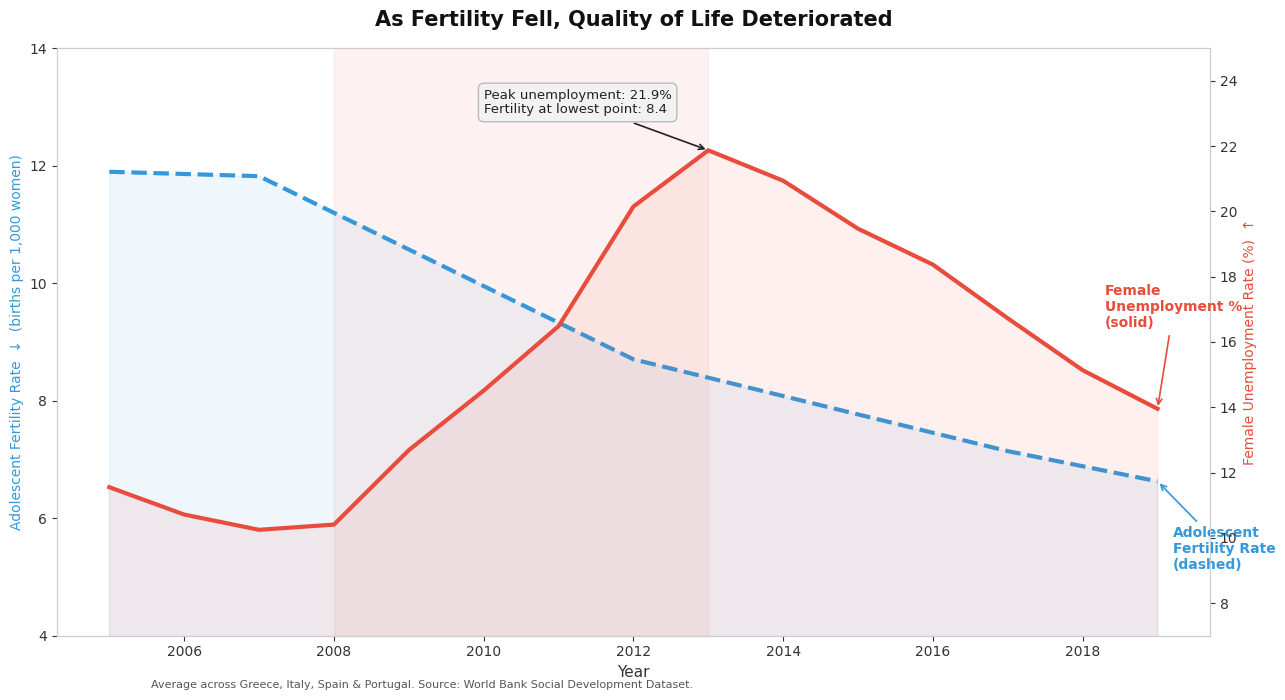

In [3]:
FERTILITY = "Adolescent fertility rate (births per 1,000 women ages 15-19)"
UNEMP_F   = "Unemployment, female (% of female labor force) (modeled ILO estimate)"

europe = ["Greece", "Italy", "Spain", "Portugal"]
eu = df[df["Country Name"].isin(europe) & df["Year"].between(2005, 2019)]
agg = eu.groupby("Year")[[FERTILITY, UNEMP_F]].mean().dropna()

BG_DARK = "#ffffff"
BG_AX   = "#ffffff"
COLOR_FERT  = "#3498db"   # blue — fertility (dashed)
COLOR_UNEMP = "#e74c3c"   # red — unemployment (solid)

fig, ax1 = plt.subplots(figsize=(13, 7), facecolor=BG_DARK)
ax1.set_facecolor(BG_AX)
ax2 = ax1.twinx()
ax2.set_facecolor(BG_AX)

# ── LINES
ax1.plot(agg.index, agg[FERTILITY], color=COLOR_FERT,
         linewidth=3, linestyle="--", zorder=3)
ax2.plot(agg.index, agg[UNEMP_F], color=COLOR_UNEMP,
         linewidth=3, linestyle="-", zorder=3)

# ── SHADED REGION under each line for visual weight ───────────────────────────
ax1.fill_between(agg.index, agg[FERTILITY], alpha=0.08, color=COLOR_FERT)
ax2.fill_between(agg.index, agg[UNEMP_F],  alpha=0.08, color=COLOR_UNEMP)

# ── TRUNCATED AXES ────────────────────────────────────────────────────────────
ax1.set_ylim(4, 14)
ax2.set_ylim(7, 25)

# ── INLINE END-OF-LINE LABELS ─────────────────────────────────────────────────
ax1.annotate("Adolescent\nFertility Rate\n(dashed)",
             xy=(2019, agg[FERTILITY].iloc[-1]),
             xytext=(2019.2, agg[FERTILITY].iloc[-1] - 1.5),
             color=COLOR_FERT, fontsize=10, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=COLOR_FERT, lw=1.2))

ax2.annotate("Female\nUnemployment %\n(solid)",
             xy=(2019, agg[UNEMP_F].iloc[-1]),
             xytext=(2018.3, agg[UNEMP_F].iloc[-1] + 2.5),
             color=COLOR_UNEMP, fontsize=10, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=COLOR_UNEMP, lw=1.2))

# ── DIFFERENCE CALLOUT at 2013 peak ──────────────────────────────────────────
peak_year = 2013
fert_at_peak  = agg.loc[peak_year, FERTILITY]
unemp_at_peak = agg.loc[peak_year, UNEMP_F]

ax2.annotate(f"Peak unemployment: {unemp_at_peak:.1f}%\nFertility at lowest point: {fert_at_peak:.1f}",
             xy=(peak_year, unemp_at_peak),
             xytext=(2010, 23),
             color="#222222", fontsize=9.5,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#f2f2f2", edgecolor="#bbbbbb"),
             arrowprops=dict(arrowstyle="->", color="#222222", lw=1.2))

# ── RECESSION BAND ────────────────────────────────────────────────────────────
ax1.axvspan(2008, 2013, alpha=0.07, color="#e74c3c")
ax1.text(2010.3, 13.2, "Financial Crisis", color="#e74c3c",
         fontsize=9, alpha=0.85, style="italic")

# ── AXIS LABELS & STYLING ─────────────────────────────────────────────────────
ax1.set_ylabel("Adolescent Fertility Rate  ↓  (births per 1,000 women)",
               color=COLOR_FERT, fontsize=10)
ax2.set_ylabel("Female Unemployment Rate (%)  ↑",
               color=COLOR_UNEMP, fontsize=10)
ax1.tick_params(colors="#333333")
ax2.tick_params(colors="#333333")
ax1.set_xlabel("Year", color="#333333", fontsize=11)

for spine in ax1.spines.values(): spine.set_color("#cccccc")
for spine in ax2.spines.values(): spine.set_color("#cccccc")

ax1.set_title("As Fertility Fell, Quality of Life Deteriorated",
              color="#111111", fontsize=15, fontweight="bold", pad=16)
fig.text(0.12, 0.01,
         "Average across Greece, Italy, Spain & Portugal. "
         "Source: World Bank Social Development Dataset.",
         color="#555555", fontsize=8)

# Note: This title is intentionally provocative but can be misleading because the chart
# directly shows fertility and unemployment only, while "quality of life" is broader
# and would require additional indicators (e.g., income, health, housing, and education).

plt.tight_layout()
plt.savefig("viz1_europe_v2.png", dpi=150, bbox_inches="tight", facecolor=BG_DARK)
print("Saved viz1_europe_v2.png")